Przed oddaniem zadania upewnij się, że wszystko działa poprawnie.
**Uruchom ponownie kernel** (z paska menu: Kernel$\rightarrow$Restart) a następnie
**wykonaj wszystkie komórki** (z paska menu: Cell$\rightarrow$Run All).

Upewnij się, że wypełniłeś wszystkie pola `TU WPISZ KOD` lub `TU WPISZ ODPOWIEDŹ`, oraz
że podałeś swoje imię i nazwisko poniżej:

In [1]:
NAME = "Malwina Juchiewicz"

---

# 2. Model TNC

Przedstawimy teraz zasadę działania modelu TNC, zaimplementujemy jego  najistotniejsze elementy oraz dokonamy ewaluacji modelu.

## 2.1. Idea modelu TNC
Dla ciągu czasowego $X \in \mathbb{R}^{D \times T}$ możemy określić okno przesuwne $X_{[t - \frac{\delta}{2}, t + \frac{\delta}{2}]}$ o długości $\delta$ wycentrowane wokół chwili $t$, które zawiera pomiary wszystkich cech w przedziale czasu $[t - \frac{\delta}{2}, t + \frac{\delta}{2}]$. Dla ułatwienia zapisu okno to będzie oznaczane jako $W_t$.

Celem metody uczenia reprezentacji będzie uzyskanie wektorowej reprezentacji dowolnego okna $W_t$.

### Temporalne sąsiedztwo
Dla okna $W_t$ zdefiniujmy jego temporalne sąsiedztwo $N_t$ jako zbiór wszystkich okien wycentrowanych w $t^*$, gdzie wartość ta jest próbkowana z rozkładu normalnego $t^* \sim \mathcal{N}(t, \eta \cdot \delta)$. Parametr $\eta$ definiuje szerokość / zakres sąsiedztwa temporalnego.

Wybór parametru $\eta$ może być oparty o wiedzę ekspercką, jednak w publikacji autorzy zaproponowali zastosowanie testu statystycznego **Augmented Dickey-Fuller (ADF)**, który będzie sprawdzać stacjonarność rozkładu próbek w sąsiedztwie temporalnym. Algorytm wyboru parametru zakłada, że rozpoczynamy od niewielkiej wartości, po czym iteracyjnie zwiększamy parametr $\eta$, powodując poszerzenie się temporalnego sąsiedztwa. Zwiększanie wartości następuje do momentu aż test statystyczny nie będzie w stanie odrzucić hipotezy zerowej.


### "Uczenie kontrastowe"
Okna w sąsiedztwie temporalnym możemy uznać jako podobne do obecnie rozważanego okna ciągu czasowego. Pozostaje zatem pytanie jak uzyskać przykłady negatywne, tak abyśmy mogli zastosować koncepcję uczenia kontrastowego. 

Moglibyśmy założyć, że wszystkie próbki (okna) poza temporalnym sąsiedztwem są przykładami negatywnymi. Może się jednak tak zdarzyć, że nawet bardzo odległe okno, jest w istocie podobne do obecnego (ma taką samą dynamikę zmian / pochodzi z tego samego rozkładu). W takiej sytuacji uczenie modelu nie byłoby efektywne. Autorzy proponują użycie podejścia **Positive-Unlabeled (PU) learning**, w którym mamy próbki bazowe, próbki pozytywne i próbki nieoznaczone. W naszym przykładzie próbkami nieoznaczonymi będą próbki spoza sąsiedztwa temporalnego.

Do próbek nieoznaczonych są przypisywane wagi $w$ (tutaj: hiperparametr metody), a każda próbka nieoznaczona jest traktowana jako połączenie próbki pozytywnej z wagą $w$ oraz próbki negatywnej z wagą $1 - w$. Zobaczymy to dalej w funkcji kosztu.

### Koder i dyskryminator
Model TNC będziemy uczyć za pomocą funkcji kosztu, która pozwala odróżniać reprezentacje próbek z tego samego sąsiedztwa temporalnego od próbek spoza sąsiedztwa.

Pierwszym elementem modelu TNC jest **koder** $\text{Enc}(W_t)$, które przekształca okno $W_t \in \mathbb{R}^{D \times \delta}$ w wektor reprezentacji $Z_t \in \mathbb{R}^M$.

Drugim elementem jest **dyskryminator** $\mathcal{D}(Z_t, Z)$ pozwalający aproksymować prawdopodobieństwo tego, że $Z$ jest reprezentacją okna w sąsiedztwie $N_t$. Innymi słowy, dla dwóch wektorów reprezentacji zwraca prawdopodobieństwo tego, że te wektory (okna) należą do tego samego sąsiedztwa temporalnego.

Przeanalizujmy rysunek przedstawiający zasadę działania modelu TNC:

![](./assets/tnc.png)

### Funkcja kosztu
W najlepszym przypadku dyskryminator powinien zwracać wartości bliskie 1 dla reprezentacji z tego samego temporalnego sąsiedztwa oraz wartość 0 w przeciwnym przypadku. Funkcja kosztu jest zdefiniowana następująco:

$$\mathcal{L} = -\mathbb{E}_{W_t\sim X}\left[ \mathbb{E}_{W_l \sim N_t}[\log \mathcal{D}(Z_t,Z_l)] +\mathbb{E}_{W_k \sim \bar{N}_t}[(1-w_t)\times \log(1 - \mathcal{D}(Z_t, Z_k)) + w_t\times \log\mathcal{D}(Z_t, Z_k)] \right]$$

## 2.2. Implementacja kodera
Ze względu na sekwencyjny charakter próbek w oknie, jako model kodera użyjemy dwukierunkowej sieci rekurencyjnego typu GRU, która na wyjściu cechy przekształci dodatkową warstwą liniową. Sieć rekurencyjna dostarcza nam stany ukryte w formie wektorów dla każdego punktu wejściowego w sekwencji, więc w celu otrzymania jednego wektora podsumowującego całą sekwencję należy dokonać odpowiedniej agregacji. W niniejszym koderze rozwarzymy dwie metody agregacji sekwencji stanów ukrytych:
* wybór ostatniego stanu ukrytego
* agregacja stanów ukrytych z wykorzystaniem mechanizmu uwagi (ang. _attention_) 

## Zadanie 2.1 (1.5 pkt)
Zaimplementuj dwie klasy dla dwóch niżej zdefiniowanych stanów ukrytych:

1. `LastHiddenAggreagation` (0.5 pkt) - metoda `forward(...)` zwraca ostatni stan ukryty z sekwencji (pamiętaj, że jest to sieć dwukierunkowa, więc ostatnie stany ukryte dla każdego z kierunku będą na przeciwnych końcach hidden states)
2. `AttentionAggregation` (1 pkt):
      * aplikuje [*scaled dot product attention*](https://arxiv.org/abs/1706.03762) oraz oblicza średnią z otrzymanych wektorów
      * podpowiedź: możesz wykorzystać `torch.nn.MultiHeadAttention` z parametrem `num_heads=1`, ale **należy mieć zrozumienie i intuicje, jak działa mechanizm uwagi i jak może pomagać w agregacji**

In [2]:
import torch
from torch import nn, Tensor
import torch.nn.functional as F

class LastHiddenAggregation(nn.Module):
    def forward(self, rnn_output: Tensor) -> Tensor:
        """Aggregates information from sequence of vectors by taking last state.
        rnn_output: Tensor with dimensions [sequence_length, batch_size, hidden_dim]
        returns: Tensor with dimensions [batch_size, hidden_dim]
        """
        forward_last  = rnn_output[-1, :, :rnn_output.shape[-1] // 2]   
        backward_last = rnn_output[0,  :, rnn_output.shape[-1] // 2:]   
        return torch.cat([forward_last, backward_last], dim=-1)      

class AttentionAggregation(nn.Module):
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=1,
            batch_first=False,
        )

    def forward(self, rnn_output: Tensor) -> Tensor:
        """Aggregates information from sequence of vectors with scaled-dot-product attention.
        rnn_output: Tensor with dimensions [sequence_length, batch_size, hidden_dim]
        returns: Tensor with dimensions [batch_size, hidden_dim]
        """
        attn_output, _ = self.attn(rnn_output, rnn_output, rnn_output)
        return attn_output.mean(dim=0)


## Zadanie 2.2 (1.5 pkt)
Zaimplementuj klasę `GRUEncoder` zgodnie z poniższymi wymaganiami:
- w metodzie `__init__()`:
  * utwórz instancję sieci GRU o wymiarze wejściowym `in_dim`, wymiarze ukrytym `hidden_dim`, która posiada jedną warstwę oraz jest dwukierunkowa (ustaw dodatkowo parametr `batch_first=False`)
  * utwórz instancję warstwy liniowej o odpowiednim wymiarze wejściowym oraz wyjściu o wymiarowości `emb_dim`
- w metodzie `_get_initial_hidden()` utwórz wektor zer jako początkowy stan ukryty
- w metodzie `forward()` przetwórz cechy okień podanych na wejściu i wyznacz wektory reprezentacji (używając sieci GRU a następnie warstwy liniowej)

In [3]:
from typing import Literal

class GRUEncoder(nn.Module):
    def __init__(
        self, 
        agg: Literal["last", "attn"], 
        in_dim: int, 
        hidden_dim: int,                  
        emb_dim: int,
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.emb_dim = emb_dim

        if agg == "last":
            self.agg = LastHiddenAggregation()
        elif agg == "attn":
            self.agg = AttentionAggregation(2*hidden_dim)
        else:
            raise ValueError(f"Invalid aggregation name")

        self.rnn = nn.GRU(
            input_size=in_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            bidirectional=True,
            batch_first=False,
        )
        self.linear = nn.Linear(2 * hidden_dim, emb_dim)
        
    def _get_initial_hidden(self, batch_size):
        device = next(self.parameters()).device
        return torch.zeros(2, batch_size, self.hidden_dim, device=device)

    def forward(self, x):
        x = x.permute(2, 0, 1)

        batch_size = x.shape[1]
        h0 = self._get_initial_hidden(batch_size)

        rnn_output, _ = self.rnn(x, h0)
        aggregated = self.agg(rnn_output)
        emb = self.linear(aggregated)

        return emb


## 2.3. Implementacja dyskryminatora
W przypadku dyskryminatora porównamy dwa proste modele, tak aby nie ryzykować przeuczeniem tego komponentu, tj. iloczyn skalarny i wielowarstwowy perceptron (MLP).

## Zadanie 2.3 (2 pkt)
Zaimplementuj 2 modele dyskryminatora zgodnie z następującymi wymaganiami:

`DotProductDiscriminator` (1 pkt):
- w metodzie `forward()` zwróc iloczyn skalarny odpowiadających sobie reprezentacji (uprzednio znormalizuj reprezentacje do jednostkowej długości)

`MLPDiscriminator` (1 pkt):
- w metodzie `__init__()` utwórz wielowarstwowy perceptron z następującymi warstwami (`d` to wymiar wejściowy):
  * warstwa liniowa o rozmiarach 2*d na 4*d
  * aktywacja ReLU
  * dropout z prawdp. równym 0.5
  * kolejna warstwa liniowa o rozmiarze 4*d na 1 
- w metodzie `forward()` dokonaj konkatenacji reprezentacji `z` oraz `z_tilde` a następnie przekaż je do perceptrona
  

In [4]:
class DotProductDiscriminator(nn.Module):
    def forward(self, z: Tensor, z_tilde: Tensor) -> Tensor:
        z_norm       = F.normalize(z,       dim=-1)
        z_tilde_norm = F.normalize(z_tilde, dim=-1)
        return (z_norm * z_tilde_norm).sum(dim=-1)

class MLPDiscriminator(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(2 * input_dim, 4 * input_dim),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(4 * input_dim, 1),
        )

    def forward(self, z: Tensor, z_tilde: Tensor) -> Tensor:
        p = torch.cat([z, z_tilde], dim=-1)
        p = self.mlp(p)
        return p.view((-1,))

## 2.4. Implementacja funkcji kosztu
W celu implementacji funkcji kosztu możemy wspomóc się gotową funkcją binarnej entropii krzyżowej, zauważając że problem uczenia dyskryminatora (a zatem całego modelu TNC) sprowadza się do problemu klasyfikacji binarnej. **Należy zaimplementować funkcję kosztu w pełnej zgodności ze wzorem podanym w publikacji (i wspomnianym w niniejszym zeszycie)**

## Zadanie 2.4 (3 pkt)
Zaimplementuj moduł implementujący funkcję kosztu modelu TNC stosując następujące wskazówki/instrukcje:
- `z_t` to reprezentacje obecnie rozważanych okien, `z_p` to reprezentacje pozytywne, natomiast `z_n` to reprezentacje nieoznaczone
- najpierw wyznacz predykcje dyskryminatora dla pary `(z_t, z_p)` oraz `(z_t, z_n)`
- przygotuj etykiety (zera i jedynki) dla par podobnych oraz różnych
- oblicz funkcję binarnej entropii krzyżowej dla wyników dyskryminatora, pamiętaj, że:
  * parę `(z_t, z_p)` chcemy traktować jako pozytywną (klasa 1)
  * parę `(z_t, z_n)` chcemy traktować jako pozytywną z wagą `w` oraz jako negatywną (klasa 0) z wagą `1 - w`
- zaimplementuj metodę `_compute_accuracy()`, która sprawdzi czy decyzje dyskryminatora są właściwe (pary pozytywne mają prawdp. `> 0.5`, a pary negatwne `< 0.5`; pamiętaj o zastosowaniu funkcji sigmoid!); wyniki uśrednij uzyskując miarę accuracy

In [5]:
from typing import Tuple


class TNCLossFunction(nn.Module):

    def __init__(
        self, 
        discriminator: Literal["dot", "mlp"], 
        emb_dim: int, 
        w: float
    ):
        super().__init__()

        if discriminator == "dot":
            self.discriminator = DotProductDiscriminator()
        elif discriminator == "mlp":
            self.discriminator = MLPDiscriminator(input_dim=emb_dim)
        else:
            raise ValueError(f"Invalid discriminator: {discriminator}")
            
        self.bce = torch.nn.BCEWithLogitsLoss()
        self.w = w

    def forward(
        self,
        z_t: Tensor,
        z_p: Tensor,
        z_n: Tensor,
    ) -> Tuple[Tensor, float]:
        d_p = self.discriminator(z_t, z_p)   
        d_n = self.discriminator(z_t, z_n)   

        ones  = torch.ones_like(d_p)
        zeros = torch.zeros_like(d_n)

        loss_p = self.bce(d_p, ones)
        loss_n = (1 - self.w) * self.bce(d_n, zeros) + self.w * self.bce(d_n, ones)

        loss = loss_p + loss_n
        
        accuracy = self._compute_accuracy(d_p=d_p, d_n=d_n)
        
        return loss, accuracy

    @staticmethod
    def _compute_accuracy(d_p: Tensor, d_n: Tensor) -> float:
        p_p = torch.sigmoid(d_p)   # powinno być > 0.5
        p_n = torch.sigmoid(d_n)   # powinno być < 0.5

        correct_p = (p_p > 0.5).float()
        correct_n = (p_n < 0.5).float()

        total   = d_p.shape[0] + d_n.shape[0]
        correct = correct_p.sum() + correct_n.sum()

        acc = (correct / total).item()
        return acc


## 2.5. Uruchomienie modelu TNC
Poniżej znajduje się kod pozwalający wyuczyć model TNC (implementacja w bibliotece PyTorch-Lightning). Ustawimy domyślny zbiór hiperparametrów i będziemy uczyć model przez 50 epok. Następnie zwizualizujemy otrzymane wektory reprezentacji i zastosujemy je w zadaniu klasyfikacji.

Moduł danych:

In [6]:
import os

import pytorch_lightning as pl
from torch.utils.data import DataLoader

from src.dataset import TNCDataset


class TrainDataModule(pl.LightningDataModule):

    def __init__(
        self,
        mc_sample_size: int,
        window_size: int,
        batch_size: int,
    ):
        super().__init__()

        self.mc_sample_size = mc_sample_size
        self.window_size = window_size
        self.batch_size = batch_size

        self.dataset = torch.load(f="./data/simulated.pt")

    def train_dataloader(self) -> DataLoader:
        return self._dataloader("x_train")

    def val_dataloader(self) -> DataLoader:
        return self._dataloader("x_val", shuffle=False)

    def _dataloader(self, split: str, shuffle: bool = True) -> DataLoader:
        data = TNCDataset(
            x=self.dataset[split],
            mc_sample_size=self.mc_sample_size,
            window_size=self.window_size,
        )
        return DataLoader(
            data,
            batch_size=self.batch_size,
            shuffle=shuffle,
            num_workers=int(os.environ.get("NUM_WORKERS", 0)),
        )


Model TNC:

In [7]:
import numpy as np
from typing import Any

class TNCModel(pl.LightningModule):

    def __init__(self, hparams: dict[str, Any]):
        super().__init__()

        self.save_hyperparameters(hparams)

        self.encoder = GRUEncoder(
            agg=hparams["agg"],
            in_dim=hparams["in_dim"],
            hidden_dim=hparams["hidden_dim"],
            emb_dim=hparams["emb_dim"],
        )
        self._loss_fn = TNCLossFunction(
            discriminator=hparams["discriminator"],
            emb_dim=self.encoder.emb_dim,
            w=self.hparams["w"],
        )

        self.training_step_outputs = []
        self.validation_step_outputs = []
        
    def forward(self, x):
        return self.encoder(x)

    def training_step(self, batch, batch_idx):
        loss, acc = self._common_step(batch)
        return {"loss": loss, "acc": acc}

    def validation_step(self, batch, batch_idx):
        loss, acc = self._common_step(batch)
        return {"loss": loss, "acc": acc}

    def on_train_batch_end(self, outputs, batch, batch_idx) -> None:
        self.training_step_outputs.append(outputs)

    def on_validation_batch_end(self, outputs, batch, batch_idx) -> None:
        self.validation_step_outputs.append(outputs)
         
    def on_validation_epoch_start(self):
        avg_loss, avg_accs = self._summarize_outputs(self.training_step_outputs)
        self.training_step_outputs = []
        
        self.log("step", self.trainer.current_epoch)
        self.log("train/loss", avg_loss, on_epoch=True, on_step=False)
        self.log("train/acc", avg_accs, on_epoch=True, on_step=False)

    def on_validation_epoch_end(self):
        avg_loss, avg_accs = self._summarize_outputs(self.validation_step_outputs)
        self.validation_step_outputs = []
        
        self.log("step", self.trainer.current_epoch)
        self.log("val/loss", avg_loss, on_epoch=True, on_step=False)
        self.log("val/acc", avg_accs, on_epoch=True, on_step=False)

    def _common_step(self, batch):
        x_t, x_p, x_n, _ = batch
        mc_sample = x_p.shape[1]
        batch_size, f_size, len_size = x_t.shape

        x_p = x_p.reshape((-1, f_size, len_size))
        x_n = x_n.reshape((-1, f_size, len_size))
        x_t = x_t.repeat(mc_sample, 1, 1)

        z_t = self.encoder(x_t)
        z_p = self.encoder(x_p)
        z_n = self.encoder(x_n)

        loss, acc = self._loss_fn(z_t=z_t, z_p=z_p, z_n=z_n)

        return loss, acc

    def configure_optimizers(self):
        return torch.optim.AdamW(
            self.parameters(),
            lr=self.hparams["lr"],
            weight_decay=self.hparams["weight_decay"],
        )
        
    @staticmethod
    def _summarize_outputs(outputs):
        losses = [out["loss"].item() for out in outputs]
        accs = [out["acc"] for out in outputs]

        avg_loss = np.mean(losses)
        avg_accs = np.mean(accs)

        return avg_loss, avg_accs

Ustawienie domyślnych hiperparametrów:

In [8]:
default_hparams = {
    "agg": "last",
    "discriminator": "dot",
    "in_dim": 3,
    "hidden_dim": 100,
    "emb_dim": 10,
    "window_size": 50,
    "mc_sample_size": 40,
    "w": 0.05,
    "num_epochs": 50,
    "lr": 1e-3,
    "weight_decay": 1e-3,
    "batch_size": 10,
    "name": "default",
}

Uczenie modelu TNC:

In [9]:
%load_ext tensorboard
%tensorboard --logdir ./data/logs --port 6006

Reusing TensorBoard on port 6006 (pid 39523), started 19:03:10 ago. (Use '!kill 39523' to kill it.)

In [10]:
datamodule = TrainDataModule(
        mc_sample_size=default_hparams["mc_sample_size"],
        window_size=default_hparams["window_size"],
        batch_size=default_hparams["batch_size"],
)
datamodule.setup("train")

In [11]:
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
import logging
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

def train(hparams):
    pl.seed_everything(42)

    datamodule = TrainDataModule(
        mc_sample_size=hparams["mc_sample_size"],
        window_size=hparams["window_size"],
        batch_size=hparams["batch_size"],
    )
    tnc = TNCModel(hparams)

    model_chkpt = ModelCheckpoint(
        dirpath=f"./data/checkpoints/{hparams['name']}/",
        filename="model",
        monitor="val/acc",
        mode="max",
        verbose=False,
    )
    trainer = pl.Trainer(
        logger=TensorBoardLogger(
            save_dir="./data/logs",
            name=f"TNC_{hparams['name']}",
            default_hp_metric=False,
        ),
        callbacks=[model_chkpt],
        num_sanity_val_steps=0,
        log_every_n_steps=1,
        max_epochs=hparams["num_epochs"],
        accelerator="cpu", # change to "cuda", if want to train on GPU
    )

    trainer.fit(model=tnc, datamodule=datamodule)
    
    
train(hparams=default_hparams)

Seed set to 42
/Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/venv/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/data/checkpoints/default exists and is not empty.
/Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
/Users/malwina.juchiewicz/Desktop/SI/uczenie-re

Epoch 49: 100%|██████████| 7/7 [00:03<00:00,  2.33it/s, v_num=3]


Ewaluacja modelu:
- wizualizacja wektorów ukrytych i surowych danych
- zadanie klasyfikacji stanu procesu generującego ciąg czasowy
- zadanie klasteryzacji wektorów reprezentacji

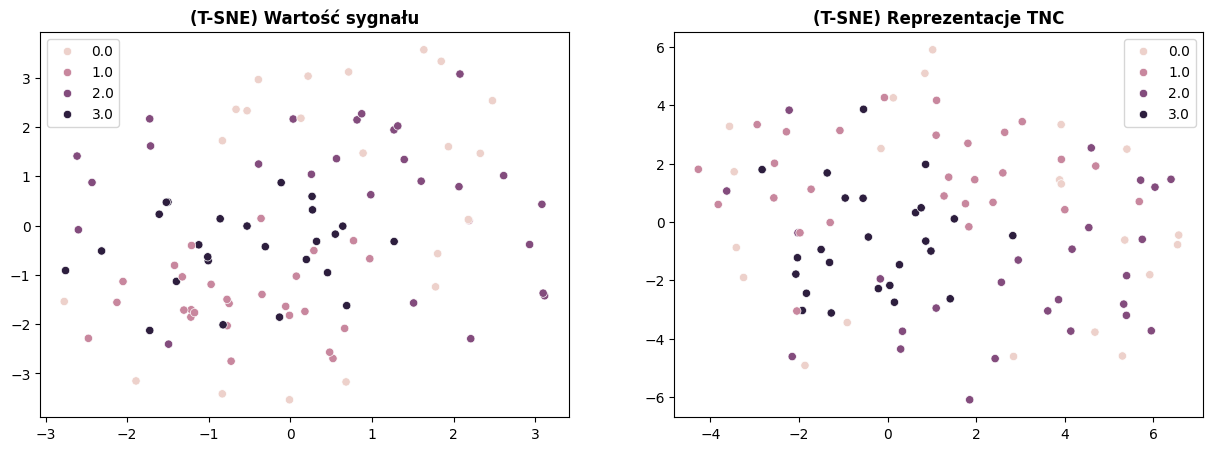

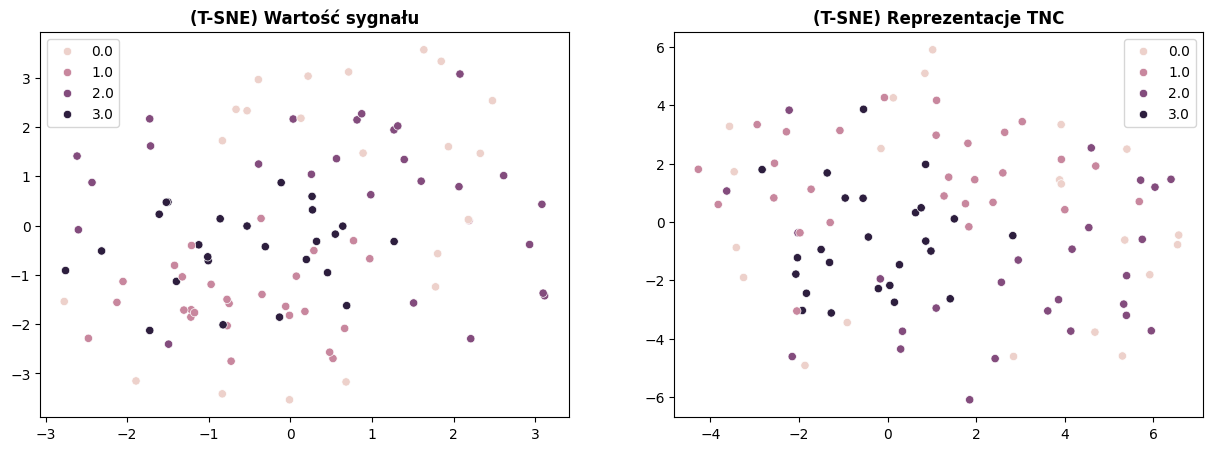

In [12]:
from src.utils import visualize_embeddings
from src.evaluations import evaluate_model


def visualize(name: str):
    best_tnc_model = TNCModel.load_from_checkpoint(
        checkpoint_path=f"./data/checkpoints/{name}/model.ckpt"
    )

    best_encoder = best_tnc_model.encoder

    dataset = torch.load("./data/simulated.pt")

    fig = visualize_embeddings(
        x_all=dataset["x_all"],
        y_all=dataset["y_all"],
        encoder=best_encoder,
        window_size=best_tnc_model.hparams["window_size"],
    )
    return fig


visualize(default_hparams["name"])

In [13]:
def evaluate_classification_clustering(name: str):
    best_tnc_model = TNCModel.load_from_checkpoint(
        checkpoint_path=f"./data/checkpoints/{name}/model.ckpt"
    )

    best_encoder = best_tnc_model.encoder

    dataset = torch.load("./data/simulated.pt")
    
    metrics = evaluate_model(
        dataset=dataset,
        encoder=best_encoder,
        window_size=best_tnc_model.hparams["window_size"],
    )
    
    return metrics


evaluate_classification_clustering(default_hparams["name"])

{'auc': {'train': np.float64(0.8997837992882362),
  'val': np.float64(0.8828687610136815),
  'test': np.float64(0.887404166328647)},
 'cluster': {'silhouette': np.float32(0.2161329),
  'davies_bouldin': np.float64(1.4895169042668814)}}

## Zadanie 2.5. Badanie wpływu metody agregacji oraz dyskryminatora TNC (1.5 pkt)
Korzystając z domyślnych hiperparametrów sprawdź, który z zaimplementowanych modułów agregacji oraz dyskryminatora dostarcza najlepszych rezultatów. Sprawdź wszystkie 4 kombinacje $\{\mathrm{last}, \mathrm{attn}\} \times \{\mathrm{dot}, \mathrm{mlp}\}$

In [14]:
import pandas as pd

# 4 kombinacje {last, attn} x {dot, mlp}
combinations = [
    ("last", "dot"),
    ("last", "mlp"),
    ("attn", "dot"),
    ("attn", "mlp"),
]

results_25 = []

for agg, disc in combinations:
    name = f"{agg}_{disc}"
    hparams = {**default_hparams, "agg": agg, "discriminator": disc, "name": name}
    print(f"\n>>> agg={agg}, discriminator={disc}")
    train(hparams=hparams)
    metrics = evaluate_classification_clustering(name=name)
    metrics["agg"]           = agg
    metrics["discriminator"] = disc
    results_25.append(metrics)
    print(f"    Metryki: {metrics}")

df_25 = pd.DataFrame(results_25).set_index(["agg", "discriminator"])
print("\n=== Wyniki ===")
print(df_25.to_string())


Seed set to 42
/Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/venv/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/data/checkpoints/last_dot exists and is not empty.
/Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
/Users/malwina.juchiewicz/Desktop/SI/uczenie-r


>>> agg=last, discriminator=dot
Epoch 49: 100%|██████████| 7/7 [00:03<00:00,  1.83it/s, v_num=3]


Seed set to 42
/Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/venv/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/data/checkpoints/last_mlp exists and is not empty.
/Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
/Users/malwina.juchiewicz/Desktop/SI/uczenie-r

    Metryki: {'auc': {'train': np.float64(0.8997837992882362), 'val': np.float64(0.8828687610136815), 'test': np.float64(0.887404166328647)}, 'cluster': {'silhouette': np.float32(0.21598758), 'davies_bouldin': np.float64(1.4889914955217094)}, 'agg': 'last', 'discriminator': 'dot'}

>>> agg=last, discriminator=mlp
Epoch 49: 100%|██████████| 7/7 [00:03<00:00,  2.14it/s, v_num=3]


Seed set to 42
/Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/venv/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/data/checkpoints/attn_dot exists and is not empty.
/Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
/Users/malwina.juchiewicz/Desktop/SI/uczenie-r

    Metryki: {'auc': {'train': np.float64(0.880014243425735), 'val': np.float64(0.8661163071753035), 'test': np.float64(0.891494176247061)}, 'cluster': {'silhouette': np.float32(0.45115295), 'davies_bouldin': np.float64(0.7162508669441252)}, 'agg': 'last', 'discriminator': 'mlp'}

>>> agg=attn, discriminator=dot
Epoch 49: 100%|██████████| 7/7 [00:04<00:00,  1.75it/s, v_num=2]


Seed set to 42
/Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/venv/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/data/checkpoints/attn_mlp exists and is not empty.
/Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
/Users/malwina.juchiewicz/Desktop/SI/uczenie-r

    Metryki: {'auc': {'train': np.float64(0.899794547839083), 'val': np.float64(0.8690607474125224), 'test': np.float64(0.9042975905281352)}, 'cluster': {'silhouette': np.float32(0.4342027), 'davies_bouldin': np.float64(0.8179297840521853)}, 'agg': 'attn', 'discriminator': 'dot'}

>>> agg=attn, discriminator=mlp
Epoch 49: 100%|██████████| 7/7 [00:04<00:00,  1.74it/s, v_num=2]
    Metryki: {'auc': {'train': np.float64(0.8209788123542325), 'val': np.float64(0.7865485781728131), 'test': np.float64(0.8363405664833061)}, 'cluster': {'silhouette': np.float32(0.5265124), 'davies_bouldin': np.float64(0.5528649364750514)}, 'agg': 'attn', 'discriminator': 'mlp'}

=== Wyniki ===
                                                                                                     auc                                                           cluster
agg  discriminator                                                                                                                                      

### Obserwacje
najlepszy auc testowy wyszedł dla attn + dot (0.904), a najlepsza klasteryzacja dla attn + mlp (silhouette 0.527, davies-bouldin 0.553). agregacja przez attention generalnie bije last pod kątem jakości klastrów — ma sens bo attention patrzy na całą sekwencję i waguje kazdy krok, zamiast ślepo brać ostatni stan. discriminator mlp tworzy lepsze klastry niż dot, bo jest bardziej ekspresywny i koder musi się bardziej "postarać" żeby go nabrać — stąd bardziej zwarte reprezentacje. natomiast attn + mlp ma najsłabszy auc ze wszystkich kombinacji, pewnie dlatego że dwa bardziej skomplikowane komponenty naraz są trudniejsze do zoptymalizowania razem

## Zadanie 2.6. Badanie hiperparametrów metody TNC (1.5 pkt)
Korzystając z podanych funkcji `train()` oraz `evaluate_classification_clustering()` zbadaj następujące hiperparametry:
- `window_size` (zbadaj co najmniej 3 wartości)
- `w` (zbadaj co najmniej 3 wartości)

Jeśli uczenie modelu będzie zbyt czasochłonne można zredukować liczbę epok. Każdy z parametrów można zbadać osobno - nie ma potrzeby przeglądania ich przekroju. Analizy powinny być prowadzone na podstawie metryk: AUC (zbiór testowy) oraz metryki klasteryzacji (Silhouette oraz Davies-Bouldin). Utwórz tabelki, które podsumują wyniki eksperymentów. Skomentuj wyniki

In [15]:
import pandas as pd

best_agg  = df_25["auc_test"].idxmax()[0]  if "auc_test" in df_25.columns else "last"
best_disc = df_25["auc_test"].idxmax()[1]  if "auc_test" in df_25.columns else "dot"

# badanie window_size
window_sizes = [25, 50, 100, 150]
results_ws = []

for ws in window_sizes:
    name = f"ws_{ws}"
    hparams = {
        **default_hparams,
        "agg": best_agg,
        "discriminator": best_disc,
        "window_size": ws,
        "name": name,
    }
    print(f"\n>>> window_size={ws}")
    train(hparams=hparams)
    metrics = evaluate_classification_clustering(name=name)
    metrics["window_size"] = ws
    results_ws.append(metrics)

df_ws = pd.DataFrame(results_ws).set_index("window_size")
print("\n=== Wyniki: badanie window_size ===")
print(df_ws.to_string())

# badanie w (waga PU learning) 
w_values = [0.01, 0.05, 0.1, 0.2]
results_w = []

for w_val in w_values:
    name = f"w_{str(w_val).replace('.', '')}".rstrip('0')
    hparams = {
        **default_hparams,
        "agg": best_agg,
        "discriminator": best_disc,
        "w": w_val,
        "name": name,
    }
    print(f"\n>>> w={w_val}")
    train(hparams=hparams)
    metrics = evaluate_classification_clustering(name=name)
    metrics["w"] = w_val
    results_w.append(metrics)

df_w = pd.DataFrame(results_w).set_index("w")
print("\n=== Wyniki: badanie w ===")
print(df_w.to_string())

Seed set to 42
/Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/venv/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/data/checkpoints/ws_25 exists and is not empty.
/Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
/Users/malwina.juchiewicz/Desktop/SI/uczenie-repr


>>> window_size=25
Epoch 49: 100%|██████████| 7/7 [00:01<00:00,  3.99it/s, v_num=2]


Seed set to 42
/Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/venv/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/data/checkpoints/ws_50 exists and is not empty.
/Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
/Users/malwina.juchiewicz/Desktop/SI/uczenie-repr


>>> window_size=50
Epoch 49: 100%|██████████| 7/7 [00:03<00:00,  2.02it/s, v_num=2]


Seed set to 42
/Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/venv/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/data/checkpoints/ws_100 exists and is not empty.
/Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
/Users/malwina.juchiewicz/Desktop/SI/uczenie-rep

...


>>> w=0.05
Epoch 49: 100%|██████████| 7/7 [00:03<00:00,  2.25it/s, v_num=1]


Seed set to 42
/Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/venv/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/data/checkpoints/w_01 exists and is not empty.
/Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
/Users/malwina.juchiewicz/Desktop/SI/uczenie-repre


>>> w=0.1
Epoch 49: 100%|██████████| 7/7 [00:02<00:00,  2.40it/s, v_num=1]


Seed set to 42
/Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/venv/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/data/checkpoints/w_02 exists and is not empty.
/Users/malwina.juchiewicz/Desktop/SI/uczenie-reprezentacji/l05-gr-3-4-mjuchiewicz/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
/Users/malwina.juchiewicz/Desktop/SI/uczenie-repre


>>> w=0.2
Epoch 49: 100%|██████████| 7/7 [00:03<00:00,  2.26it/s, v_num=1]

=== Wyniki: badanie w ===
                                                                                       auc                                                           cluster
w                                                                                                                                                           
0.01   {'train': 0.9037545033909479, 'val': 0.885708070387385, 'test': 0.8917903322686016}  {'silhouette': 0.21950732, 'davies_bouldin': 1.7269752616146148}
0.05   {'train': 0.8997837992882362, 'val': 0.8828687610136815, 'test': 0.887404166328647}  {'silhouette': 0.21598758, 'davies_bouldin': 1.4889914955217094}
0.10  {'train': 0.9087439241480751, 'val': 0.8850345183625477, 'test': 0.8985247059042424}  {'silhouette': 0.19581863, 'davies_bouldin': 1.8514804801381874}
0.20  {'train': 0.9121163803272161, 'val': 0.8878867691853004, 'test': 0.9022609335141452}   {'silhouette': 0.19

### Obserwacje
#### window_size:
najlepiej wyszło window_size=50 — zarówno auc (0.887) jak i silhouette (0.216) są najlepsze, davies-bouldin też najnizszy. przy ws=25 okno jest za małe zeby sieć mogła wychwycić sensowną dynamikę. przy ws=100 i ws=150 okno zaczyna obejmować przejścia między stanami HMM co psuje załozenie ze sąsiedztwo jest stacjonarne — stąd gorsze wyniki i to dość konsekwentnie wraz ze wzrostem rozmiaru okna

#### w:
tutaj róznice są duzo mniejsze niz przy window_size, wszystkie auc testowe mieszczą się w przedziale 0.887–0.902. auc rośnie trochę wraz z w, klasteryzacja jest najlepsza dla małych wartości (w=0.05 daje najlepszy davies-bouldin). ma to sens — małe w oznacza ze mocniej traktujemy próbki spoza sąsiedztwa jako negatywne, co daje lepiej oddzielone klastry. większe w lekko poprawia auc bo zmniejsza pewność etykiet negatywnych, co może pomagać gdy odległe okna akurat są z tego samego stanu HMM. generalnie model nie jest super wrażliwy na ten parametr